min scaled sizes: 50.0, median scaled sizes: 62.9929536716771, max scaled sizes: 500.0
Size metric 'number_of_sig_info_in_pathway': min=0, median=2245.5, max=77771
Scaled marker sizes for legend: min=50.0, median=63.0, max=500.0


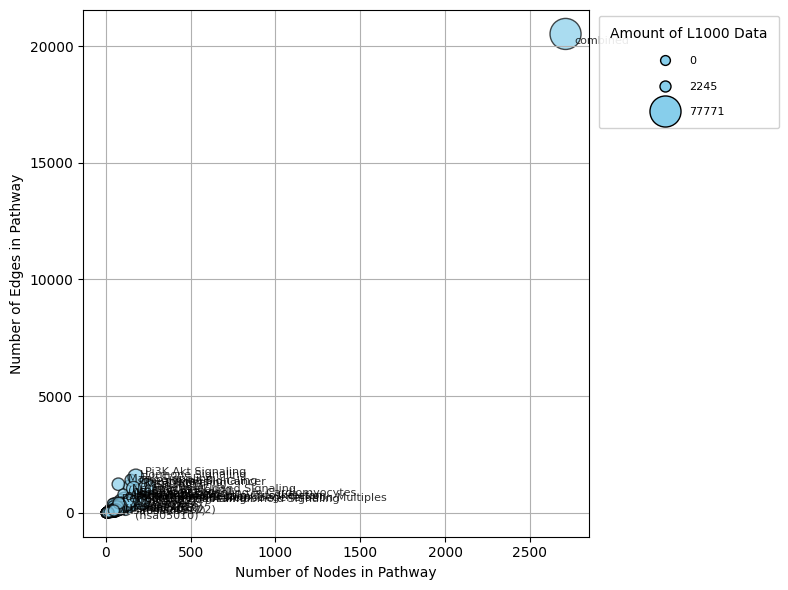

In [1]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from matplotlib.lines import Line2D

# ========================
# CONFIGURATION
# ========================
# Metrics to use
x_metric = "number_of_nodes"
y_metric = "number_of_edges"
size_metric = "number_of_sig_info_in_pathway"

# Plot labels and title
xlabel = "Number of Nodes in Pathway"
ylabel = "Number of Edges in Pathway"
title = "Overview of Processed KEGG Pathways"

# Percentile for isolated points annotation
isolated_percentile = 92  # top 8%

# ------------------------
# Load data
# ------------------------
with open("kegg_data/kegg_nodes_metrics.json") as f:
    data = json.load(f)

names = list(data.keys())
x = np.array([data[name][x_metric] for name in names])
y = np.array([data[name][y_metric] for name in names])
sizes = np.array([data[name][size_metric] for name in names])

# ------------------------
# Helper functions
# ------------------------
def scale_sizes(values, min_size=50, max_size=500):
    """Scale marker sizes for scatter plot."""
    vmin, vmax = np.min(values), np.max(values)
    if vmax == vmin:
        return np.full_like(values, min_size, dtype=float)
    return min_size + (values - vmin) / (vmax - vmin) * (max_size - min_size)

def find_isolated_points(x, y, percentile=92, k=5):
    """Return indices of points that are isolated based on k-nearest neighbor distance."""
    coords = np.column_stack([x, y])
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(coords)
    distances, _ = nbrs.kneighbors(coords)
    avg_dist = distances[:, 1:].mean(axis=1)  # exclude self-distance
    threshold = np.percentile(avg_dist, percentile)
    isolated_idx = np.where(avg_dist >= threshold)[0]
    return isolated_idx

# ------------------------
# Plot
# ------------------------
plt.figure(figsize=(8, 6))

# Scatter plot
scaled_sizes = scale_sizes(sizes)
sc = plt.scatter(x, y, s=scaled_sizes, alpha=0.7, edgecolors='k', c='skyblue')

print(f"min scaled sizes: {np.min(scaled_sizes)}, median scaled sizes: {np.median(scaled_sizes)}, max scaled sizes: {np.max(scaled_sizes)}")
# Annotate isolated points
isolated_idx = find_isolated_points(x, y, percentile=isolated_percentile)
for i in isolated_idx:
    name = names[i]
    if "(" in name:
        name = name.replace("(", "\n(")
    plt.text(x[i]+0.02*max(x), y[i]-0.02*max(y), name, fontsize=8, alpha=0.8)


# ------------------------
# Correct size legend
# ------------------------
# Calculate min, median, max of the actual data
size_min = np.min(sizes)
size_median = np.median(sizes)
size_max = np.max(sizes)

min_size = 50
max_size = 500

# Apply scaling to individual legend values
# These represent marker AREA (same as scatter plot's 's' parameter)
marker_min = min_size + (size_min - np.min(sizes)) / (np.max(sizes) - np.min(sizes)) * (max_size - min_size)
marker_median = min_size + (size_median - np.min(sizes)) / (np.max(sizes) - np.min(sizes)) * (max_size - min_size)
marker_max = min_size + (size_max - np.min(sizes)) / (np.max(sizes) - np.min(sizes)) * (max_size - min_size)

print(f"Size metric '{size_metric}': min={size_min}, median={size_median}, max={size_max}")
print(f"Scaled marker sizes for legend: min={marker_min:.1f}, median={marker_median:.1f}, max={marker_max:.1f}")

# Create custom legend handles
# Convert from area (scatter's 's') to linear size (Line2D's 'markersize')
# The correct conversion is: markersize = sqrt(area), NOT sqrt(area/pi)
# Create custom legend handles
legend_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='skyblue', 
           markeredgecolor='k', markersize=np.sqrt(marker_min), label=f'{int(size_min)}'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='skyblue', 
           markeredgecolor='k', markersize=np.sqrt(marker_median), label=f'{int(size_median)}'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='skyblue', 
           markeredgecolor='k', markersize=np.sqrt(marker_max), label=f'{int(size_max)}')
]

# Better legend placement and styling
# bbox_to_anchor=(1.05, 1) places legend outside on the right
plt.legend(
    handles=legend_handles,
    title="Amount of L1000 Data",
    fontsize=8,
    title_fontsize=10,
    frameon=True,
    framealpha=0.9,
    loc='upper left',           # anchor point of the legend box
    bbox_to_anchor=(1.01, 1),   # position relative to the axes (x, y)
    borderpad=1,
    labelspacing=1.4,           # spacing between entries
    handletextpad=1.2,          # spacing between marker and label
    handlelength=2               # length of marker in legend
)


plt.xlabel(xlabel)
plt.ylabel(ylabel)
# plt.title(title)
plt.grid(True)
plt.tight_layout()
plt.show()


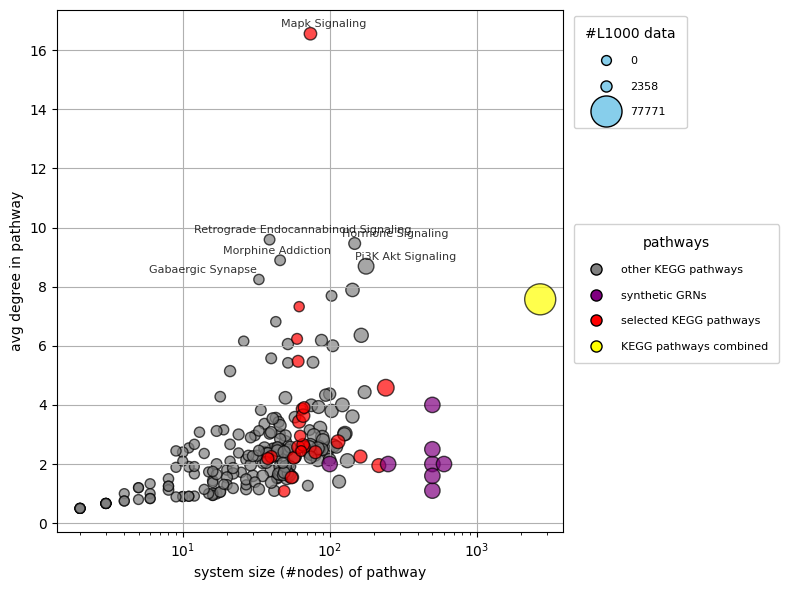

In [14]:
import json
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from matplotlib.lines import Line2D
import re

def clean_pathway_name(name):
    # Removes trailing " (hsa12345)"
    return re.sub(r"\s*\(hsa\d+\)$", "", name)


# ========================
# CONFIGURATION
# ========================
x_metric = "number_of_nodes"
y_metric = "average_degree"
size_metric = "number_of_sig_info_in_pathway"

# Axis scale configuration
log_x_axis = True
log_y_axis = False


xlabel = "system size (#nodes) of pathway"
ylabel = "avg degree in pathway"
title = "Overview of Processed KEGG Pathways"

isolated_percentile = 97  # top 8% for isolated points annotation

# ------------------------
# Load data
# ------------------------
with open("kegg_data/kegg_nodes_metrics_paper.json") as f:
    data = json.load(f)

names = list(data.keys())
x = np.array([data[name][x_metric] for name in names])
y = np.array([data[name][y_metric] for name in names])
sizes = np.array([data[name][size_metric] for name in names])

# ------------------------
# Pathway colors
# ------------------------
pathway_colors = {
    "synth_ref": "purple",
    "synth_graph_1": "purple",
    "synth_graph_2": "purple",
    "synth_graph_3": "purple",
    "synth_graph_4": "purple",
    "synth_graph_5": "purple",
    "synth_graph_6": "purple",
    "synth_graph_7": "purple",
    "Apoptosis (hsa04210)": "red",
    "Breast Cancer (hsa05224)": "red",
    "Central Carbon Metabolism In Cancer (hsa05230)": "red",
    "Circadian Entrainment (hsa04713)": "red",
    "Colorectal Cancer (hsa05210)": "red",
    "Egfr Signaling (hsa01521)": "red",
    "Endocrine Resistance (hsa01522)": "red",
    "Estrogen Signaling (hsa04915)": "red",
    "Human Papillomavirus Infection (hsa05165)": "red",
    "Igsf Cam Signaling (hsa04517)": "red",
    "Il 17 Signaling (hsa04657)": "red",
    "Primary Immunodeficiency (hsa05340)": "red",
    "Mapk Signaling (hsa04010)": "red",
    "Mtor Signaling (hsa04150)": "red",
    "Pathways Of Neurodegeneration Multiples (hsa05022)": "red",
    "Non Small Cell Lung Cancer (hsa05223)": "red",
    "Olfactory Transduction (hsa04740)": "red",
    "P53 Signaling (hsa04115)": "red",
    "Pathways In Cancer (hsa05200)": "red",
    "Pd L1 Expression And Pd 1 Checkpoint In Cancer (hsa05235)": "red",
    "Prolactin Signaling (hsa04917)": "red",
    "Prostate Cancer (hsa05215)": "red",
    "Tgf Beta Signaling (hsa04350)": "red",
    "Tuberculosis (hsa05152)": "red",
    "Vascular Smooth Muscle Contraction (hsa04270)": "red",
    "combined": "yellow"
}
colors = [pathway_colors.get(name, "grey") for name in names]

# ------------------------
# Helper functions
# ------------------------
def scale_sizes(values, min_size=50, max_size=500):
    vmin, vmax = np.min(values), np.max(values)
    if vmax == vmin:
        return np.full_like(values, min_size, dtype=float)
    return min_size + (values - vmin) / (vmax - vmin) * (max_size - min_size)

def find_isolated_points(x, y, percentile=92, k=20, log_x=False, log_y=False):
    x_trans = x.copy()
    y_trans = y.copy()

    # Transform to log space if needed (must be positive)
    if log_x:
        if np.any(x_trans <= 0):
            raise ValueError("x contains non-positive values. Cannot use log distance.")
        x_trans = np.log10(x_trans)

    if log_y:
        if np.any(y_trans <= 0):
            raise ValueError("y contains non-positive values. Cannot use log distance.")
        y_trans = np.log10(y_trans)

    coords = np.column_stack([x_trans, y_trans])
    nbrs = NearestNeighbors(n_neighbors=k + 1).fit(coords)
    distances, _ = nbrs.kneighbors(coords)

    avg_dist = distances[:, 1:].mean(axis=1)
    threshold = np.percentile(avg_dist, percentile)
    isolated_idx = np.where(avg_dist >= threshold)[0]

    return isolated_idx


# ------------------------
# Scatter plot
# ------------------------
plt.figure(figsize=(8, 6))

scaled_sizes = scale_sizes(sizes)

# Separate grey points (background) from colored points (foreground)
grey_mask = np.array([c == "grey" for c in colors])
colored_mask = ~grey_mask

# Plot grey points first (lower zorder = background)
if np.any(grey_mask):
    plt.scatter(x[grey_mask], y[grey_mask], s=scaled_sizes[grey_mask], 
                alpha=0.7, edgecolors='k', c='grey', zorder=1)

# Plot colored points second (higher zorder = foreground)
if np.any(colored_mask):
    colored_colors = [colors[i] for i in range(len(colors)) if colored_mask[i]]
    sc = plt.scatter(x[colored_mask], y[colored_mask], s=scaled_sizes[colored_mask], 
                     alpha=0.7, edgecolors='k', c=colored_colors, zorder=2)

# # xlim = 750
# xlim = max(x)*1.1
# plt.xlim(0,xlim)
# # plt.ylim()

# Annotate isolated points
isolated_idx = find_isolated_points(
    x, y,
    percentile=isolated_percentile,
    k=20,
    log_x=log_x_axis,
    log_y=log_y_axis
)
for i in isolated_idx:
    name = clean_pathway_name(names[i])
    if name == "combined":
        continue
    #if plot within xlim and ylim
    # if x[i] > 0 and x[i] < xlim and y[i] > 0 and y[i] < max(y)*1.1:
    plt.text(x[i]-0.01*max(x), y[i]+0.013*max(y), name, fontsize=8, alpha=0.8)

# ------------------------
# Size legend
# ------------------------
size_min, size_median, size_max = np.min(sizes), np.median(sizes), np.max(sizes)
min_size, max_size = 50, 500

marker_min = min_size + (size_min - np.min(sizes)) / (np.max(sizes) - np.min(sizes)) * (max_size - min_size)
marker_median = min_size + (size_median - np.min(sizes)) / (np.max(sizes) - np.min(sizes)) * (max_size - min_size)
marker_max = min_size + (size_max - np.min(sizes)) / (np.max(sizes) - np.min(sizes)) * (max_size - min_size)

size_handles = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='skyblue', 
           markeredgecolor='k', markersize=np.sqrt(marker_min), label=f'{int(size_min)}'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='skyblue', 
           markeredgecolor='k', markersize=np.sqrt(marker_median), label=f'{int(size_median)}'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='skyblue', 
           markeredgecolor='k', markersize=np.sqrt(marker_max), label=f'{int(size_max)}')
]

# ------------------------
# Color legend
# ------------------------
color_label_map = {
    "red": "selected KEGG pathways",
    "purple": "synthetic GRNs",
    "yellow": "KEGG pathways combined",
    "grey": "other KEGG pathways"
}

unique_colors = sorted(set(colors))

color_handles = [
    Line2D(
        [0], [0],
        marker='o',
        color='w',
        markerfacecolor=c,
        markeredgecolor='k',
        markersize=8,
        label=color_label_map.get(c, c)
    )
    for c in unique_colors
]

# ------------------------
# Plot styling and combined legends
# ------------------------
plt.xlabel(xlabel)
plt.ylabel(ylabel)
#plt.title(title)

# ------------------------
# Axis scaling
# ------------------------
if log_x_axis:
    # avoid log(0)
    if np.any(x <= 0):
        raise ValueError("x contains non-positive values. Cannot use log scale.")
    plt.xscale("log")

if log_y_axis:
    # avoid log(0)
    if np.any(y <= 0):
        raise ValueError("y contains non-positive values. Cannot use log scale.")
    plt.yscale("log")


plt.grid(True)

# Place size legend
legend1 = plt.legend(handles=size_handles, title="#L1000 data", fontsize=8,
                     title_fontsize=10, frameon=True, framealpha=0.9, loc='upper left',
                     bbox_to_anchor=(1.01, 1), borderpad=1, labelspacing=1.4, handletextpad=1.2, handlelength=2)

# Place color legend below size legend
plt.gca().add_artist(legend1)
plt.legend(handles=color_handles, title="pathways", fontsize=8,
           title_fontsize=10, frameon=True, framealpha=0.9, loc='upper left',
           bbox_to_anchor=(1.01, 0.6), borderpad=1, labelspacing=1.4, handletextpad=1.2, handlelength=2)

plt.tight_layout()
plt.show()
